# **Necessary Imports**

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import tensorflow as tf
import keras
from google.colab import drive
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, precision_recall_curve, auc
import sklearn
from tensorflow.keras import regularizers
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
sklearn.set_config(display='diagram')
drive.mount('/content/drive')

# Hide warnings
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [127]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer-telco-churn/data/cleaned/cleaned_data.csv')

# **Data Preprocessing**

In [128]:
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [146]:
binary_cols = []
numerical_cols = []
ordinal_cols = []
multinomial_cols = []

for col in df.columns:
  if col == 'Churn' or col == 'customerID':
    continue

  unique_vals = df[col].nunique()
  if df[col].dtype == 'object':
    if unique_vals == 2:
      print(f"{col}: Binary")
      binary_cols.append(col)
    elif col == 'Contract':
      ordinal_cols.append(col)
      print(f"{col}: Ordinal")
    else:
      multinomial_cols.append(col)
      print(f"{col}: Multinomial")
  else:
    numerical_cols.append(col)
    print(f"{col}: Numerical")

categorical_columns = X.select_dtypes(include='object').columns
numerical_columns = X.select_dtypes(include=np.number).columns

Unnamed: 0: Numerical
gender: Binary
SeniorCitizen: Numerical
Partner: Binary
Dependents: Binary
tenure: Numerical
PhoneService: Binary
MultipleLines: Multinomial
InternetService: Multinomial
OnlineSecurity: Multinomial
OnlineBackup: Multinomial
DeviceProtection: Multinomial
TechSupport: Multinomial
StreamingTV: Multinomial
StreamingMovies: Multinomial
Contract: Ordinal
PaperlessBilling: Binary
PaymentMethod: Multinomial
MonthlyCharges: Numerical
TotalCharges: Numerical


## **Applying Column Transformer**

In [130]:
def preprocess_data(df):
  if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

  df.dropna(inplace=True)

  binary_cols = []
  numerical_cols = []
  ordinal_cols = []
  multinomial_cols = []

  for col in df.columns:
    if col == 'Churn' or col == 'customerID':
      continue

    unique_vals = df[col].nunique()
    if df[col].dtype == 'object':
      if unique_vals == 2:
        print(f"{col}: Binary")
        binary_cols.append(col)
      elif col == 'Contract':
        ordinal_cols.append(col)
        print(f"{col}: Ordinal")
      else:
        multinomial_cols.append(col)
        print(f"{col}: Multinomial")
    else:
      numerical_cols.append(col)
      print(f"{col}: Numerical")

  ordinal_categories = [[
      'Month-to-month',
      'One year',
      'Two year'
  ]]

  preprocessor = ColumnTransformer(
      transformers=[
          ('binary', OrdinalEncoder(), binary_cols),  #
          ('ordinal', OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
          ('nominal', OneHotEncoder(drop='first', sparse_output=False), multinomial_cols),  # Produce a numpy array and avoid dummy trap variable
          ('numeric', Pipeline([
              ('imputer', SimpleImputer(strategy='median')),
              ('scaler', StandardScaler())
          ]), numerical_cols)
      ]
  )
  return df, preprocessor

In [131]:
df, preprocessor = preprocess_data(df)

X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

Unnamed: 0: Numerical
gender: Binary
SeniorCitizen: Numerical
Partner: Binary
Dependents: Binary
tenure: Numerical
PhoneService: Binary
MultipleLines: Multinomial
InternetService: Multinomial
OnlineSecurity: Multinomial
OnlineBackup: Multinomial
DeviceProtection: Multinomial
TechSupport: Multinomial
StreamingTV: Multinomial
StreamingMovies: Multinomial
Contract: Ordinal
PaperlessBilling: Binary
PaymentMethod: Multinomial
MonthlyCharges: Numerical
TotalCharges: Numerical


# **Model Training**

## **Train Test Split**

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [133]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [134]:
ohe = preprocessor.named_transformers_['nominal']
ohe_cols = ohe.get_feature_names_out(multinomial_cols)

# Combine all processed column names
processed_columns = binary_cols + ordinal_cols + list(ohe_cols) + numerical_cols


# Apply smote to handle class imbalance
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)
X_train_balanced = pd.DataFrame(X_train_balanced, columns=processed_columns)
y_train_balanced = pd.Series(y_train_balanced)

In [135]:
categorical_cols = [col for col in X_train_balanced.columns if col not in numerical_cols]
X_cat = X_train_balanced[categorical_cols]
X_num = X_train_balanced[numerical_cols]
chi2_selector = SelectKBest(chi2, k=15)
chi2_selector.fit(X_cat, y_train_balanced)

SelectKBest(k=15, score_func=<function chi2 at 0x7d2f71e9de40>)

In [136]:
# Get  boolean mask of top features
mask = chi2_selector.get_support()

# List of selected categorical features
selected = X_cat.columns[mask]
print("Selected features:", list(selected))

# Reduce X cat to only selected columns
X_cat_selected = X_cat[selected]

# Combine with numeric features
X_train_selected = pd.concat([X_cat_selected, X_num], axis=1)

# Repeat for X test for testing
cat_indices = [processed_columns.index(col) for col in selected] # Only top 15 categorical
num_indices = [processed_columns.index(col) for col in numerical_cols] # numerical columns

X_test_cat_selected = X_test_processed[:, cat_indices]
X_test_num_selected = X_test_processed[:, num_indices]

# Combine categorical and numerical
X_test_selected = np.hstack([X_test_cat_selected, X_test_num_selected])

print(X_train_selected.shape)
print(X_test_selected.shape)

Selected features: ['Dependents', 'PaperlessBilling', 'Contract', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check']
(8276, 20)
(1409, 20)


In [137]:
def build_nn(input_dim):
  """
  Builds a neural network for churn prediction
  """

  model = keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim, )),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    # Output layer
    tf.keras.layers.Dense(1, activation='sigmoid')
  ])
  return model
model = build_nn(X_train_selected.shape[1])

In [138]:
# Get model summary
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [139]:
# Compile the model
def compile_model(model, learning_rate=0.001):   # default value for learning rate
  optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  metrics = [
      keras.metrics.BinaryAccuracy(name='accuracy'),   # predicted probs >= 0.5 then class 1
      keras.metrics.Precision(name='precision'),
      keras.metrics.Recall(name='recall'),
      keras.metrics.AUC(name='auc'),  # seperates positive and negative classes across all probability thresholds
      keras.metrics.AUC(name='prc', curve='PR') # Precision recall AUC (heavily focuses on positive class behaviour and performance under imbalance)
  ]

  model.compile(
      optimizer = optimizer,
      loss = 'binary_crossentropy',
      metrics = metrics
  )
  return model

model = compile_model(model, learning_rate=0.001)

In [152]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_balanced),
    y=y_train_balanced
)

class_weight_dict = dict(zip(np.unique(y_train_balanced), class_weights))
print(class_weight_dict)

{np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


In [154]:
callbacks = [
      tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,  # stop is val loss does not improve in 15 epochs
        mode='min', # lower loss is better
        restore_best_weights=True,
        verbose=1
      )
  ]
history = model.fit(
      X_train_selected,
      y_train,
      batch_size=64,
      epochs=50,
      validation_data=(X_test_selected, y_test),
      callbacks=callbacks,
      class_weight=class_weight_dict
)

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 8276
'y' sizes: 5634
'sample_weight' sizes: 5634


## **Class Weights**

In [148]:
mi_scores = mutual_info_classif(X_train_selected, y_train_balanced, discrete_features='auto', random_state=42)
mi_scores = pd.Series(mi_scores, index=X_train_selected.columns).sort_values(ascending=False)
print(mi_scores)

tenure                                   0.296116
Contract                                 0.158820
MonthlyCharges                           0.104480
PaymentMethod_Electronic check           0.085782
PaperlessBilling                         0.068073
InternetService_Fiber optic              0.062410
Dependents                               0.056574
OnlineSecurity_Yes                       0.051377
TotalCharges                             0.050682
TechSupport_Yes                          0.050428
StreamingMovies_No internet service      0.043291
PaymentMethod_Credit card (automatic)    0.041912
OnlineSecurity_No internet service       0.041565
OnlineBackup_No internet service         0.041340
StreamingTV_No internet service          0.040494
TechSupport_No internet service          0.040239
DeviceProtection_No internet service     0.036295
InternetService_No                       0.035291
SeniorCitizen                            0.013507
Unnamed: 0                               0.000000


{np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


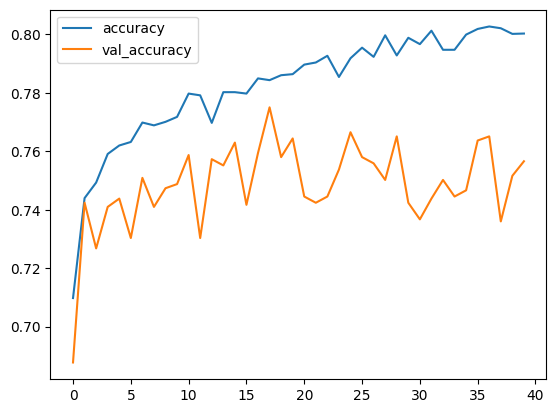

In [141]:
# Plot accuracy and validation accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

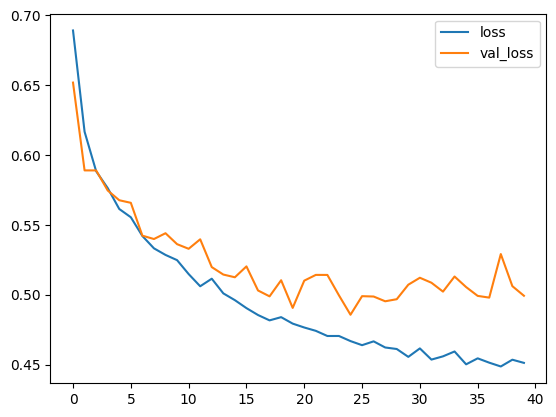

In [142]:
# Plot loss and validation loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

In [143]:
# Evaluate the neural network
print(model.evaluate(X_test, y_test))

ValueError: Invalid dtype: object

In [ ]:
predictions = model.predict(X_test)
cm = confusion_matrix(y_test, predictions.round())
cm

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# **Hyperparameter Tuning**